In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
image=cv2.imread("answer_sheet.jpeg")


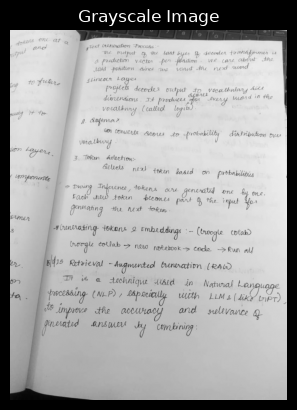

In [10]:
gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

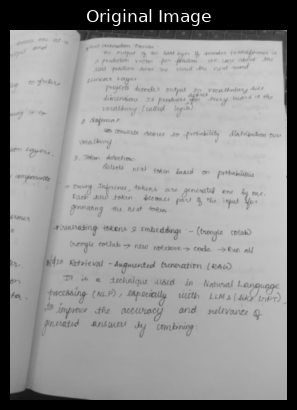

In [9]:
blur=cv2.GaussianBlur(gray,(5,5),0)
plt.imshow(cv2.cvtColor(blur, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")
plt.show()

In [11]:
binary = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)[1]

In [12]:
height, width = binary.shape
resized = cv2.resize(
    binary,
    (width * 2, height * 2),
    interpolation=cv2.INTER_CUBIC
)

In [13]:
cv2.imwrite("processed_answer_sheet.png", resized)


True

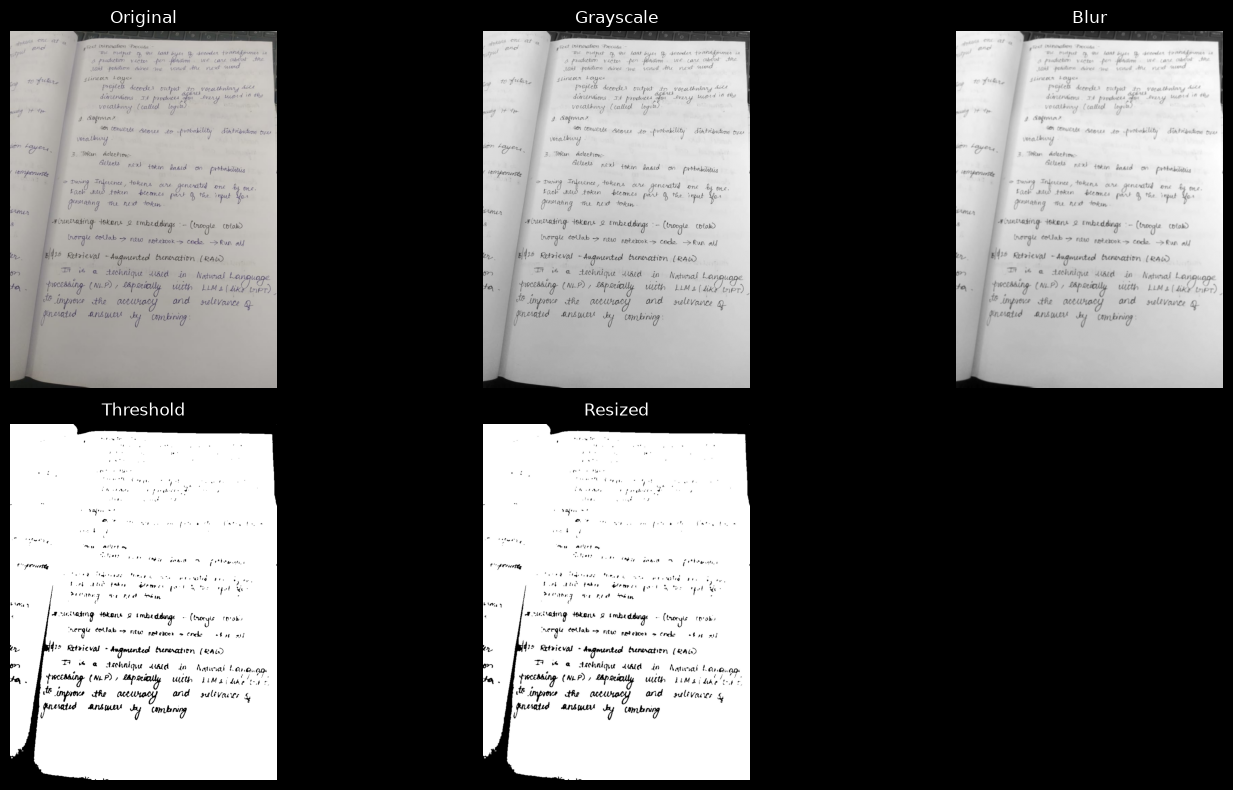

In [14]:
titles = [
    "Original",
    "Grayscale",
    "Blur",
    "Threshold",
    "Resized"
]

images = [
    cv2.cvtColor(image, cv2.COLOR_BGR2RGB),
    gray,
    blur,
    binary,
    resized
]

plt.figure(figsize=(15, 8))

for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
from pdf2image import convert_from_path

pages = convert_from_path(
    "CI Assignment.pdf",
    poppler_path=r"D:\Downloads\Release-26.02.0-0\poppler-26.02.0\Library\bin"   # Windows only (adjust path)
)

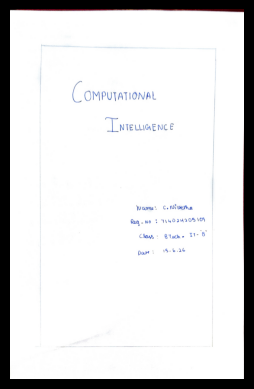

In [19]:
import matplotlib.pyplot as plt

plt.imshow(pages[0])
plt.axis("off")
plt.show()

In [20]:
import cv2
import numpy as np

image = np.array(pages[0])
image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

In [22]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

binary = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)[1]

In [26]:
import pytesseract

pytesseract.pytesseract.tesseract_cmd = (
    r"C:\Program Files\Tesseract-OCR\tesseract.exe"
)

text = pytesseract.image_to_string(binary)

print(text)

( ompurationaL

“Lwtewuiaence

Wosmes C.Mivetiia
Ran - wo 5 440 9H205 104
Choy > RB tach + 11-8




In [30]:
from pdf2image import convert_from_path

pages = convert_from_path(
    "CI Assignment.pdf",
    poppler_path=r"D:\Downloads\Release-26.02.0-0\poppler-26.02.0\Library\bin"
)

for i, page in enumerate(pages):
    image = np.array(page)
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    text = pytesseract.image_to_string(gray)

    print(f"----- Page {i+1} -----")
    print(text)

----- Page 1 -----
( omputationat

“[ wtewimenc

Wosme. Cv Wi vetro
Rag - wo + 14024205 104
Chaos. B Tach » 11-8


----- Page 2 -----
Ve * 3
4 \! a\
5 ON
\\ 3
Gy
A) A&))
Derm First Seance =
SyackR yosst J: S sade Ros LD

|
3 € ON
dsp CE) gay cas)
1 pe tr 3
co) %\ 0€ SOE G3 /
3a C0) - dip CE) eae
dp © SS)

Para SPRPEPOA

RBeenoth Fast Search

egrcl-
BAG cops

Parh 2 S$ -> DPB APE FOP


----- Page 3 -----
Unnirorm Coy
tsJ

ra ia \

, fA, 0,8)
{ 49 yy

A £0, ,cr4

¢ ir
\ 4

O LCE Bai]

i em yw AS
CL E,B, Gay OeyF

an io m
C®, ha, oy 7 My>
U > NUN

m

le A\ ie)
5 Z
Av {HO
Ag
ay hy
L
10
Mm
15
19) yo ©

SyaR nostd:
JS>CR )) (A ~

SEARCY |

US Porn
Q

SPC

a> O©ra+s

a “? va

\§
eJ

) * Bye
oh

AGEN


----- Page 4 -----
BAY ( 3) | pws
ays (oO) | \Alz b 4

ASK CZ) |
; {
AX ON )

AISC®)
| Ags CF)
“agp (9)
dys Co?

Reeaniw Fest Searcy:

LZ st Quaws =

Guaus =

mec ys fa) z\ $\7

Qquous =

aes Pox’

a?Z27o7t17 Oo PE TR PLB

myty: A 2.3.70)

yAT

A772 >08>5>8 >g

—— j its
, Po

12] quaue = (tlol F

In [32]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

image = Image.open("answer_sheet.jpeg").convert("RGB")

pixel_values = processor(images=image, return_tensors="pt").pixel_values

generated_ids = model.generate(pixel_values)

text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(text)

ValueError: Couldn't instantiate the backend tokenizer from one of: 
(1) a `tokenizers` library serialization file, 
(2) a slow tokenizer instance to convert or 
(3) an equivalent slow tokenizer class to instantiate and convert. 
You need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.